In [18]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,FunctionTransformer,OrdinalEncoder
from sklearn.compose import ColumnTransformer


In [19]:
df = pd.read_csv("../data/processed/Clean_data.csv")
df.head()

,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,minutes_to_first_check_after_waking,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,25,...,9,6,4,6,8,4,No,No,No,At-risk
1,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,26,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,12,...,8,7,3,2,3,5,No,No,No,Moderate
3,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,21,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,19,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


# Selecting Colummns according to there behaviours

In [20]:
from sklearn.model_selection import train_test_split

skew_ccol = ['daily_screen_hours','daily_notifications','minutes_to_first_check_after_waking','platforms_used_count',
             'low_mood_score_0to27']

normal_numeric_col = ['age','avg_sleep_hours','anxiety_score_0to27','life_satisfaction_1to10',
                     'loneliness_1to10','self_esteem_1to10','fomo_1to10','social_comparison_1to10']

one_hot_encode_col = ['gender','occupation','region','most_used_platform','uses_screen_time_limits']
ordinal_encode_col = ['night_time_use','attempted_digital_detox','seeks_mental_health_support']


feature_col = skew_ccol+normal_numeric_col+one_hot_encode_col+ordinal_encode_col
X = df[feature_col]
y = df['wellbeing_band']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42,stratify=y)


# Making Pipeline For Encoding And Scalling (Preprocessing)

In [21]:
# Skewed data
log_pipeline = Pipeline(steps=[
    ("log_transform",FunctionTransformer(np.log1p,feature_names_out='one-to-one')),
    ("Scaler",StandardScaler())
])

# normal Numeric Col

numeric_pipeline = Pipeline(steps=[
    ("Scaler",StandardScaler())
])

# Ordinal_col

ordinal_pipeline = Pipeline(steps=[
    ("ordinal_encode",OrdinalEncoder(categories=[  
        ['Never', 'Sometimes', 'Often', 'Every night'],
        ['No', 'Yes, failed', 'Yes, succeeded'],
        ['No', 'Considering it', 'Yes']]))
])

# One Hot encoding

one_hot_pipline = Pipeline(steps=[
    ("onehot_encoding",OneHotEncoder(handle_unknown="ignore"))
])

# Apply Column Tranformer

In [22]:
preprocesor = ColumnTransformer(
    transformers=[
        ('log',log_pipeline,skew_ccol),
        ('num',numeric_pipeline,normal_numeric_col),

        ('ordinal',ordinal_pipeline,ordinal_encode_col),
        ('one',one_hot_pipline,one_hot_encode_col)
    ]
)

# Encode Target Column

In [23]:
mapping = {
    'At-risk': 0,
    'Moderate': 1,
    'Good': 2
}

y_train = y_train.map(mapping)
y_test = y_test.map(mapping)

# Test Base Line Model(Logistic Regression)

In [24]:
from sklearn.linear_model import LogisticRegression
lgR = Pipeline([
    ("preprocesor",preprocesor),
    ("model1",LogisticRegression(max_iter=1000))
])

lgR.fit(X_train,y_train)
lgR_pred_test =  lgR.predict(X_test)
model_pred_training = lgR.predict(X_train)


# Apply Cross validation Test

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lgR,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross-validation scores: [0.93163265 0.91020408 0.92755102 0.92653061 0.93979592]
Mean Accuracy: 0.9271428571428573
Standard Deviation: 0.00967183315189615


# Testing Random Forest Without HyperParameter

In [26]:
from sklearn.ensemble import RandomForestClassifier
model_rf = Pipeline([
    ("Preprocessor",preprocesor),
    ("random forest",RandomForestClassifier(random_state=42))
]
)

model_rf.fit(X_train,y_train)
model_rf_pred_test = model_rf.predict(X_test)
model_rf_pred_training = model_rf.predict(X_train)


In [27]:
from sklearn.metrics import classification_report
print("Testing Data","-"*50)
print(classification_report(y_test, model_rf_pred_test))


Testing Data --------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       292
           1       0.99      1.00      1.00      1130
           2       1.00      1.00      1.00       678

    accuracy                           1.00      2100
   macro avg       1.00      0.99      0.99      2100
weighted avg       1.00      1.00      1.00      2100



In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model_rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(scores)
print("Mean CV Accuracy:", scores.mean())


[0.99795918 0.99693878 0.99897959 0.99489796 0.99897959]
Mean CV Accuracy: 0.9975510204081631


# Testing SVM 

In [29]:
from sklearn.svm import SVC

svc_model = Pipeline([
    ("preprocessor",preprocesor),
    ("Model",SVC())
]
)

model_svc = svc_model.fit(X_train,y_train)
model_svc_pred = svc_model.predict(X_test)
print(classification_report(y_test, model_rf_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       292
           1       0.99      1.00      1.00      1130
           2       1.00      1.00      1.00       678

    accuracy                           1.00      2100
   macro avg       1.00      0.99      0.99      2100
weighted avg       1.00      1.00      1.00      2100



# Apply  Cross validation

In [30]:
cv_svc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

score_svc = cross_val_score(
    model_svc,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(score_svc)
print("Mean",score_svc.mean())

[0.92755102 0.90816327 0.92755102 0.9122449  0.92653061]
Mean 0.9204081632653061


# HyperParameter Tunning On Random Forest 

In [31]:
from sklearn.model_selection import RandomizedSearchCV
para_grid = {
    'random forest__n_estimators'        : [100,200,500],
    'random forest__max_depth'           : [5,10,15],
    'random forest__min_samples_split'   : [2,5,10],
    'random forest__min_samples_leaf'    : [1,2,4]
}
randomize_cv = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=para_grid,
    n_iter=15,
    cv = 5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)


randomize_cv.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`

In [32]:
randomize_cv.best_params_

{'random forest__n_estimators': 500,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

# Selecting  Best Model By Hyper pAramter Tunning 

In [33]:
rf_best_pipline = randomize_cv.best_estimator_
rf_best_pred = rf_best_pipline.predict(X_test)

print(classification_report(y_test,rf_best_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       292
           1       0.99      1.00      1.00      1130
           2       1.00      1.00      1.00       678

    accuracy                           1.00      2100
   macro avg       1.00      0.99      1.00      2100
weighted avg       1.00      1.00      1.00      2100



# Compare All Model To FInd Best Model 

In [34]:
# Pass output_dict=True to generate a dictionary that pandas can read
report_dict_lg = classification_report(y_test, lgR_pred_test, output_dict=True)
report_dict_rf = classification_report(y_test, model_rf_pred_test, output_dict=True)
report_dict_svc = classification_report(y_test, model_svc_pred, output_dict=True)
report_dict_best_rf = classification_report(y_test, rf_best_pred, output_dict=True)

# Convert to DataFrame
logistic_model = pd.DataFrame(report_dict_lg)
random_forest_model = pd.DataFrame(report_dict_rf)
SVC_model_ = pd.DataFrame(report_dict_svc)
best_rf_model = pd.DataFrame(report_dict_best_rf)


In [35]:
logistic_model

,0,1,2,accuracy,macro avg,weighted avg
precision,1.000000,0.920277,0.893778,0.922857,0.938019,0.922807
recall,0.982877,0.939823,0.868732,0.922857,0.930477,0.922857
f1-score,0.991364,0.929947,0.881077,0.922857,0.934130,0.922709
support,292.000000,1130.000000,678.000000,0.922857,2100.000000,2100.000000


In [36]:
random_forest_model

,0,1,2,accuracy,macro avg,weighted avg
precision,1.000000,0.993843,1.0,0.996667,0.997948,0.996687
recall,0.976027,1.000000,1.0,0.996667,0.992009,0.996667
f1-score,0.987868,0.996912,1.0,0.996667,0.994927,0.996652
support,292.000000,1130.000000,678.0,0.996667,2100.000000,2100.000000


In [37]:
SVC_model_

,0,1,2,accuracy,macro avg,weighted avg
precision,0.992063,0.915371,0.901449,0.92,0.936295,0.921540
recall,0.856164,0.938053,0.917404,0.92,0.903874,0.920000
f1-score,0.919118,0.926573,0.909357,0.92,0.918349,0.919978
support,292.000000,1130.000000,678.000000,0.92,2100.000000,2100.000000


In [38]:
best_rf_model

,0,1,2,accuracy,macro avg,weighted avg
precision,1.000000,0.994718,1.0,0.997143,0.998239,0.997158
recall,0.979452,1.000000,1.0,0.997143,0.993151,0.997143
f1-score,0.989619,0.997352,1.0,0.997143,0.995657,0.997132
support,292.000000,1130.000000,678.0,0.997143,2100.000000,2100.000000


# rf_best_model Is final Model 

In [39]:
import joblib
joblib.dump(rf_best_pipline,"../models/Mental_Health_Score_Prediction.pkl")

['../models/Mental_Health_Score_Prediction.pkl']

In [40]:
rf = rf_best_pipline.steps[-1][1]

In [ ]:
rf    #Get your trained Random Forest

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [ ]:
# Transform the test data
X_test_transformed = rf_best_pipline.named_steps[
    'Preprocessor'
].transform(X_test)

In [ ]:
 #Get feature names
feature_names = rf_best_pipline.named_steps[
    'Preprocessor'
].get_feature_names_out()

In [44]:
X_test_transformed

array([[-1.33993424, -1.48342775,  1.07437481, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.65365971,  1.14850075, -1.44196569, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.31857968,  0.19264248, -0.87253196, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-2.2275533 , -2.27571718, -2.9848528 , ...,  0.        ,
         0.        ,  1.        ],
       [ 1.70926529,  1.03860524, -0.25202365, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.65365971, -1.22836753,  0.61735277, ...,  1.        ,
         1.        ,  0.        ]], shape=(2100, 42))

In [46]:
# Create SHAP explainer
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(
    X_test_transformed
)

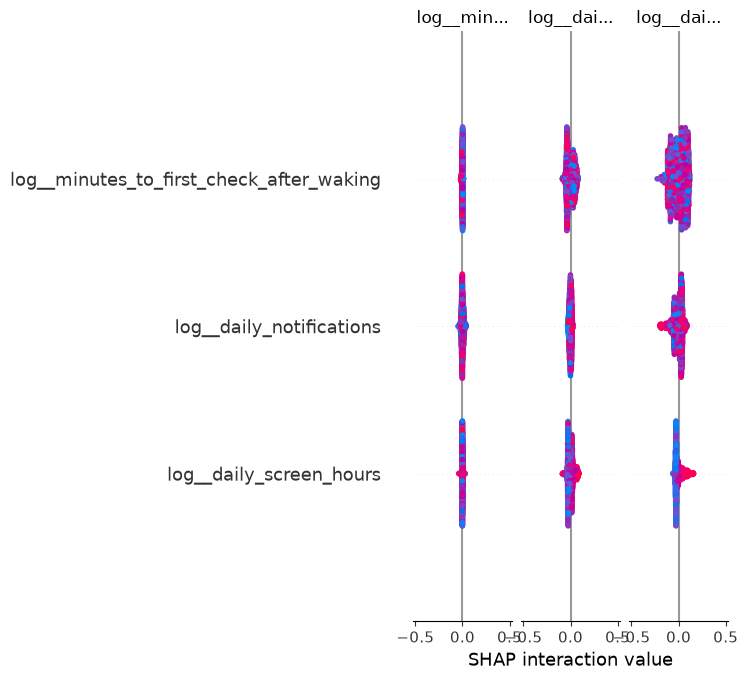

In [47]:
# Plot feature importance
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

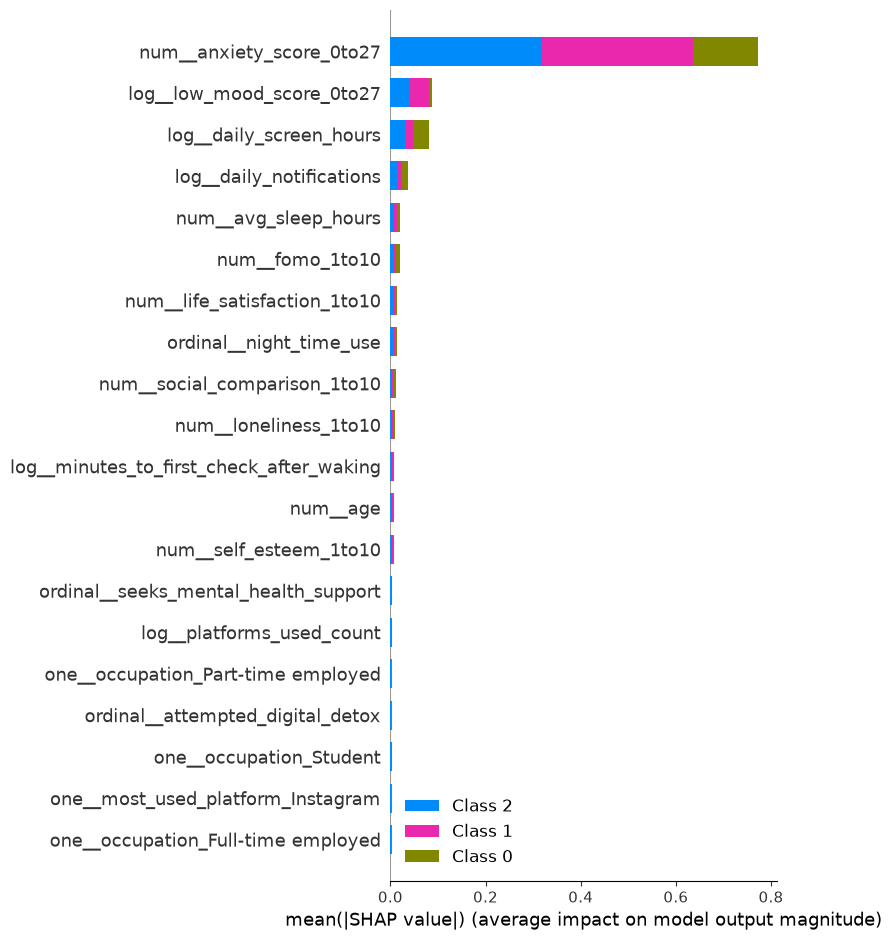

In [48]:
# Bar plot
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [52]:
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_best_pipline.steps[-1][1].feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))
importance.to_csv("../data/preprocessed/Important_features.csv",index = False)

                                     Feature  Importance
7                   num__anxiety_score_0to27    0.676027
4                  log__low_mood_score_0to27    0.064078
0                    log__daily_screen_hours    0.055855
1                   log__daily_notifications    0.028342
6                       num__avg_sleep_hours    0.019350
2   log__minutes_to_first_check_after_waking    0.015576
5                                   num__age    0.015364
11                           num__fomo_1to10    0.013316
12              num__social_comparison_1to10    0.011238
9                      num__loneliness_1to10    0.011107
8               num__life_satisfaction_1to10    0.010317
10                    num__self_esteem_1to10    0.010214
3                  log__platforms_used_count    0.008570
13                   ordinal__night_time_use    0.007779
14          ordinal__attempted_digital_detox    0.004492


In [49]:
print(feature_col)

['daily_screen_hours', 'daily_notifications', 'minutes_to_first_check_after_waking', 'platforms_used_count', 'low_mood_score_0to27', 'age', 'avg_sleep_hours', 'anxiety_score_0to27', 'life_satisfaction_1to10', 'loneliness_1to10', 'self_esteem_1to10', 'fomo_1to10', 'social_comparison_1to10', 'gender', 'occupation', 'region', 'most_used_platform', 'uses_screen_time_limits', 'night_time_use', 'attempted_digital_detox', 'seeks_mental_health_support']


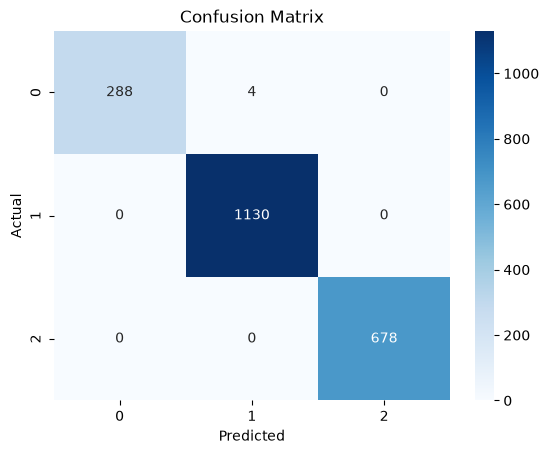

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_best_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

# Get feature names after preprocessing
feature_names = model_rf.named_steps['Preprocessor'].get_feature_names_out()

# Get Random Forest feature importance
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model_rf.named_steps['classifier'].feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

                                     Feature  Importance
7                   num__anxiety_score_0to27    0.639467
4                  log__low_mood_score_0to27    0.065092
0                    log__daily_screen_hours    0.051913
1                   log__daily_notifications    0.029751
6                       num__avg_sleep_hours    0.021959
2   log__minutes_to_first_check_after_waking    0.018626
5                                   num__age    0.017899
11                           num__fomo_1to10    0.015009
12              num__social_comparison_1to10    0.013461
10                    num__self_esteem_1to10    0.012782
8               num__life_satisfaction_1to10    0.012288
9                      num__loneliness_1to10    0.012245
3                  log__platforms_used_count    0.010989
13                   ordinal__night_time_use    0.008418
15      ordinal__seeks_mental_health_support    0.005628
